# Band-Pass Wave Stacking — 140°W (TPOSE24 Ri5)

Compares TAO ADCP vs TPOSE24 (Ri5) zonal velocity at 0°N/140°W, and shows model-only at 1°N and 1°S for three frequency bands:
- **Band 1:** >6.5-day periods (low-frequency)
- **Band 2:** 1.2–6.5 day periods
- **Band 3:** 21–29-hour periods (near-diurnal / near-inertial)

**Figure 1** (main): 3 rows × 2 cols — left=TAO, right=TPOSE at 0°N  
**Figure 2**: 3 rows × 2 cols — left=TPOSE 1°N, right=TPOSE 1°S

In [1]:
SUBFOLDER = '3month_Ri5'
RUN_DIR   = f'/data/SO3/edavenport/tpose24/oct2012_TP6Vel_{SUBFOLDER}'
PROF_FILE = f'{RUN_DIR}/PROF_eq/TAO_WO_2012_ADCP_v2_model.nc'
SAVE_DIR  = SUBFOLDER   # relative to wave_stacking/ (notebook cwd)
import os; os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean.cm as cmo
import pandas as pd
import warnings
from scipy.signal import butter, filtfilt

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10})

## 1. Load TAO + MITprof model at 0°N, 140°W (hourly)

In [3]:
ds         = xr.open_dataset(PROF_FILE)
lons       = ds['prof_lon'].values
lats       = ds['prof_lat'].values
depths_tao = ds['prof_depth'].values        # (62,)  10–315 m
dates_raw  = ds['prof_YYYYMMDD'].values
times_raw  = ds['prof_HHMMSS'].values
U_all      = ds['prof_U'].values.astype(float)
Ue_all     = ds['prof_Uestim'].values.astype(float)

def parse_dt(d, t):
    d, t = int(d), int(t)
    return pd.Timestamp(d // 10000, (d % 10000) // 100, d % 100,
                        t // 10000, (t % 10000) // 100, t % 100)

timestamps = np.array([parse_dt(d, t) for d, t in zip(dates_raw, times_raw)])

# 0°N, 140°W only; require model output
mask  = (lons == -140.) & (lats == 0.)
ok    = ~np.isnan(Ue_all[mask]).any(axis=1)
t_raw = timestamps[mask][ok]
U_raw = U_all[mask][ok]
Ue_raw= Ue_all[mask][ok]

# Regular hourly grid
t_hrly = pd.date_range(t_raw[0].floor('h'), t_raw[-1].ceil('h'), freq='1h')
n_hrly, n_z = len(t_hrly), len(depths_tao)
U_tao  = np.full((n_hrly, n_z), np.nan)
Ue_0N  = np.full((n_hrly, n_z), np.nan)

for i, tr in enumerate(t_raw):
    idx = int(round((tr - t_hrly[0]).total_seconds() / 3600))
    if 0 <= idx < n_hrly:
        U_tao[idx]  = U_raw[i]
        Ue_0N[idx]  = Ue_raw[i]

Z_tao = -depths_tao   # negative for plotting (surface at top)
print(f'TAO: {n_hrly} hourly steps,  {t_hrly[0].date()} – {t_hrly[-1].date()}')
print(f'Depths: {depths_tao[0]:.0f}–{depths_tao[-1]:.0f} m  ({n_z} levels)')

TAO: 2183 hourly steps,  2012-10-01 – 2012-12-30
Depths: 10–315 m  (62 levels)


## 2. Load TPOSE model at 0°N, 1°N, 1°S (3-hourly)

Reads from a pre-built cache NetCDF.  
If the cache is missing, run `build_model_cache.py` first (~15 min on NFS).

In [4]:
cache_file = f'{SAVE_DIR}/cache_model_points.nc'

if not os.path.exists(cache_file):
    raise FileNotFoundError(
        f'Cache not found: {cache_file}\n'
        'Run wave_stacking/build_model_cache.py {SUBFOLDER} first (takes ~15 min on NFS).')

print('Loading cached model point time series …')
ds_c     = xr.open_dataset(cache_file)
U_0N_mod = ds_c['U_0N'].values
U_1N_mod = ds_c['U_1N'].values
U_1S_mod = ds_c['U_1S'].values
t_mod    = pd.DatetimeIndex(ds_c['time'].values)
Z_mod    = ds_c['depth'].values

print(f'Model: {len(t_mod)} 3-hourly steps,  {t_mod[0].date()} – {t_mod[-1].date()}')
print(f'Depths: {-Z_mod[0]:.1f}–{-Z_mod[-1]:.1f} m  ({len(Z_mod)} levels)')

Loading cached model point time series …
Model: 727 3-hourly steps,  2012-10-01 – 2012-12-30
Depths: 0.5–307.5 m  (77 levels)


## 3. Band-pass filter function

In [5]:
def bpfilt(data_2d, dt_h, band_periods_h, order=4):
    """
    Apply zero-phase Butterworth filter to each depth column independently.

    band_periods_h : tuple
        (T_hi,)       → low-pass  (keeps periods > T_hi)
        (T_lo, T_hi)  → band-pass (keeps T_lo < period < T_hi)
        Periods in hours.
    NaN columns skipped; gaps linearly interpolated before filtering, then masked back.
    """
    fs  = 1.0 / dt_h
    nyq = fs / 2.0

    if len(band_periods_h) == 1:
        Wn = min((1.0 / band_periods_h[0]) / nyq, 0.99)
        b, a = butter(order, Wn, btype='low')
    else:
        T_lo, T_hi = band_periods_h
        Wn = [max((1.0 / T_hi) / nyq, 1e-4),
              min((1.0 / T_lo) / nyq, 0.99)]
        b, a = butter(order, Wn, btype='band')

    out = np.full_like(data_2d, np.nan)
    t   = np.arange(data_2d.shape[0])
    min_pts = max(60, 6 * int(max(band_periods_h) / dt_h))

    for iz in range(data_2d.shape[1]):
        col = data_2d[:, iz]
        ok  = np.isfinite(col)
        if ok.sum() < min_pts:
            continue
        col_f = np.interp(t, t[ok], col[ok])
        col_f -= col_f.mean()
        try:
            filt = filtfilt(b, a, col_f)
        except Exception:
            continue
        filt[~ok] = np.nan
        out[:, iz] = filt
    return out

## 4. Apply filters

In [6]:
# Band definitions: (label, period-range tuple in hours)
BANDS = [
    ('>6.5-day',    (6.5 * 24,)),           # lowpass  at 156 h
    ('1.2–6.5-day', (1.2 * 24, 6.5 * 24)), # bandpass 28.8–156 h
    ('21–29-hour',  (21., 29.)),             # bandpass 21–29 h
]

print('Filtering TAO obs (hourly) …')
filt_tao = [bpfilt(U_tao,     1.0, bp) for _, bp in BANDS]

print('Filtering TPOSE 0N MITprof (hourly) …')
filt_0N  = [bpfilt(Ue_0N,    1.0, bp) for _, bp in BANDS]

print('Filtering TPOSE diag_state 1N/1S (3-hourly) …')
filt_1N  = [bpfilt(U_1N_mod, 3.0, bp) for _, bp in BANDS]
filt_1S  = [bpfilt(U_1S_mod, 3.0, bp) for _, bp in BANDS]

# Mask TPOSE 0N wherever TAO obs is NaN (point-by-point)
tao_nan = np.isnan(U_tao)
for i in range(len(BANDS)):
    filt_0N[i] = np.where(tao_nan, np.nan, filt_0N[i])

print('Done.')

Filtering TAO obs (hourly) …
Filtering TPOSE 0N MITprof (hourly) …
Filtering TPOSE diag_state 1N/1S (3-hourly) …
Done.


## 5. Plotting helpers

In [7]:
import matplotlib.ticker as mticker

def fmt_time_ax(ax, zoom=False):
    if zoom:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

def depth_yax(ax):
    ax.set_ylim([-315, 0])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{-y:.0f}'))
    ax.set_ylabel('Depth (m)')

def cf_plot(ax, t_arr, z_arr, data, vmax, cmap=cmo.balance, n_levels=100):
    """Filled contour plot on a (time × depth) axes."""
    levels = np.linspace(-vmax, vmax, n_levels + 1)
    cf = ax.contourf(t_arr, z_arr, data.T,
                     levels=levels, cmap=cmap, extend='both')
    return cf

def make_colorbar(fig, cf, axes_row, vmax):
    """Add a shared colorbar with ~5–7 sensible ticks."""
    cb = fig.colorbar(cf, ax=axes_row.tolist(), shrink=0.85, pad=0.01)
    cb.set_label('U  (m s⁻¹)')
    tick_step = _nice_tick(vmax / 3)
    ticks = np.arange(-vmax, vmax + tick_step / 2, tick_step)
    cb.set_ticks(ticks[np.abs(ticks) <= vmax * 1.01])
    cb.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3g'))
    return cb

def _nice_tick(x):
    """Round x up to a 'nice' value (1, 2, 5 × 10^n)."""
    import math
    exp   = math.floor(math.log10(x)) if x > 0 else 0
    frac  = x / 10 ** exp
    for nice in [1, 2, 2.5, 5, 10]:
        if frac <= nice:
            return nice * 10 ** exp
    return 10 ** (exp + 1)

## 6. Figure 1 — TAO vs TPOSE at 0°N, 140°W  (full period)

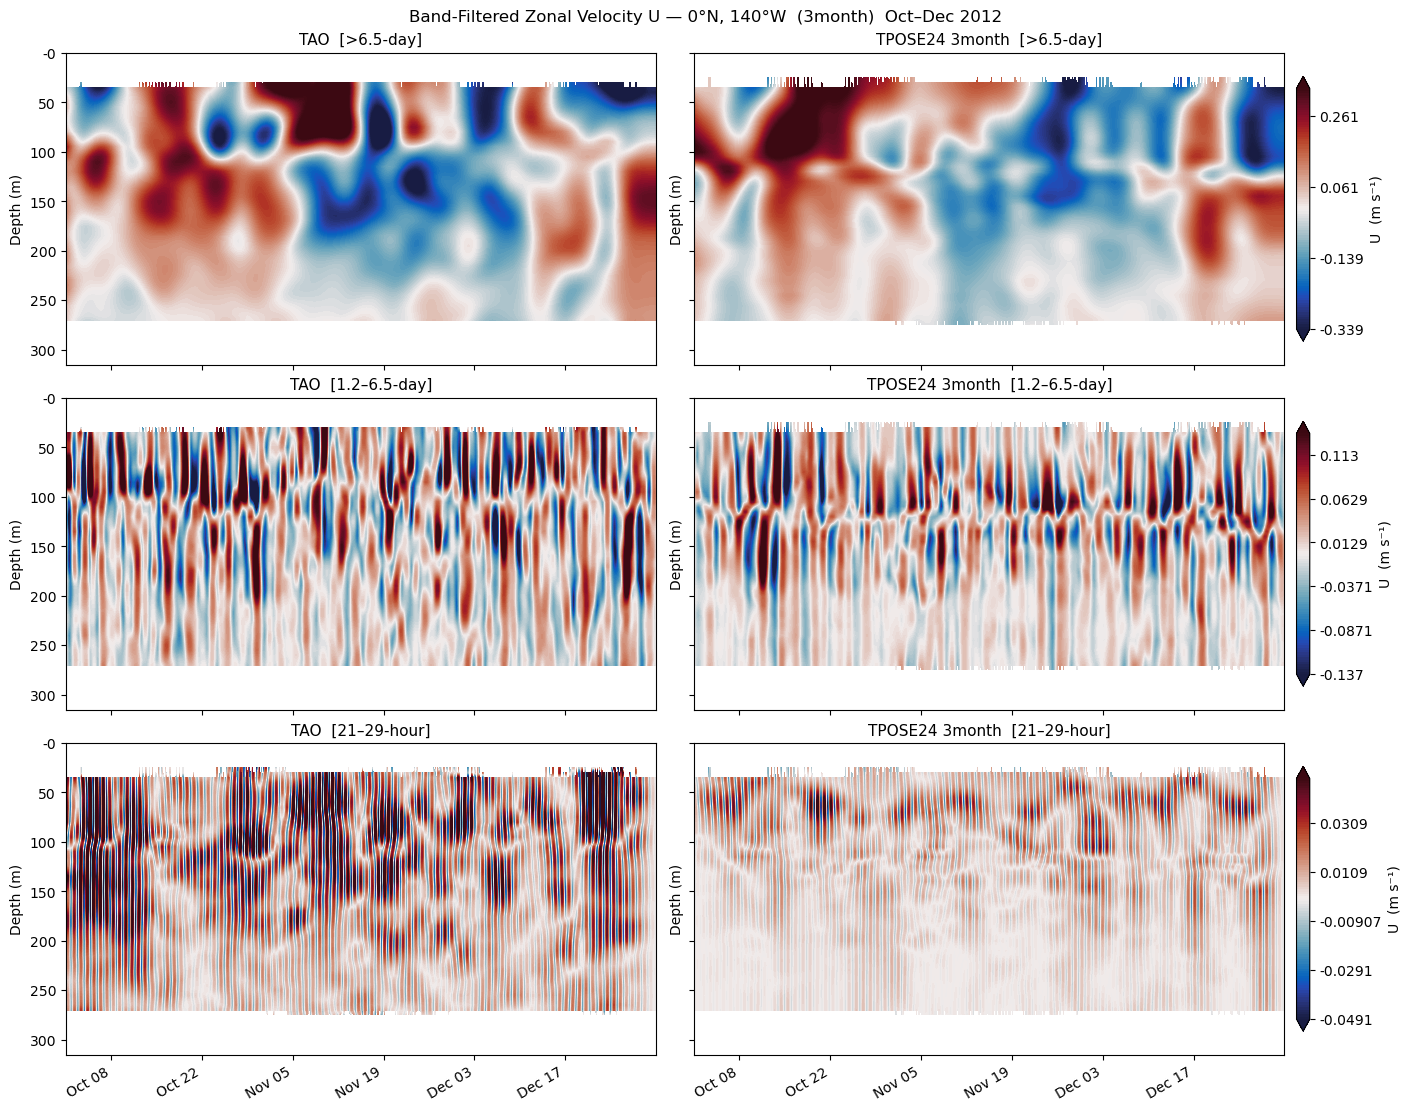

Saved 3month/fig1_wave_stacking_0N_140W.png


In [8]:
t_hrly_arr = t_hrly.to_pydatetime()

fig, axes = plt.subplots(3, 2, figsize=(14, 11),
                          sharex=True, sharey=True, constrained_layout=True)
fig.suptitle(f'Band-Filtered Zonal Velocity U — 0°N, 140°W  ({SUBFOLDER})  Oct–Dec 2012',
             fontsize=12)

vmaxes_fig1 = []
for row, (label, bp) in enumerate(BANDS):
    d_tao = filt_tao[row]
    d_mod = filt_0N[row]
    valid  = np.concatenate([d_tao[np.isfinite(d_tao)], d_mod[np.isfinite(d_mod)]])
    vmax   = max(np.nanpercentile(np.abs(valid), 97), 0.005)
    vmaxes_fig1.append(vmax)

    cf0 = cf_plot(axes[row, 0], t_hrly_arr, Z_tao, d_tao, vmax)
    cf1 = cf_plot(axes[row, 1], t_hrly_arr, Z_tao, d_mod, vmax)

    axes[row, 0].set_title(f'TAO  [{label}]')
    axes[row, 1].set_title(f'TPOSE24 {SUBFOLDER}  [{label}]')
    for ax in axes[row]:
        depth_yax(ax)

    make_colorbar(fig, cf1, axes[row], vmax)

for ax in axes[-1]:
    fmt_time_ax(ax)

out1 = f'{SAVE_DIR}/fig1_wave_stacking_0N_140W.png'
fig.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', out1)

## 7. Figure 2 — TPOSE 1°N vs 1°S, 140°W  (full period)

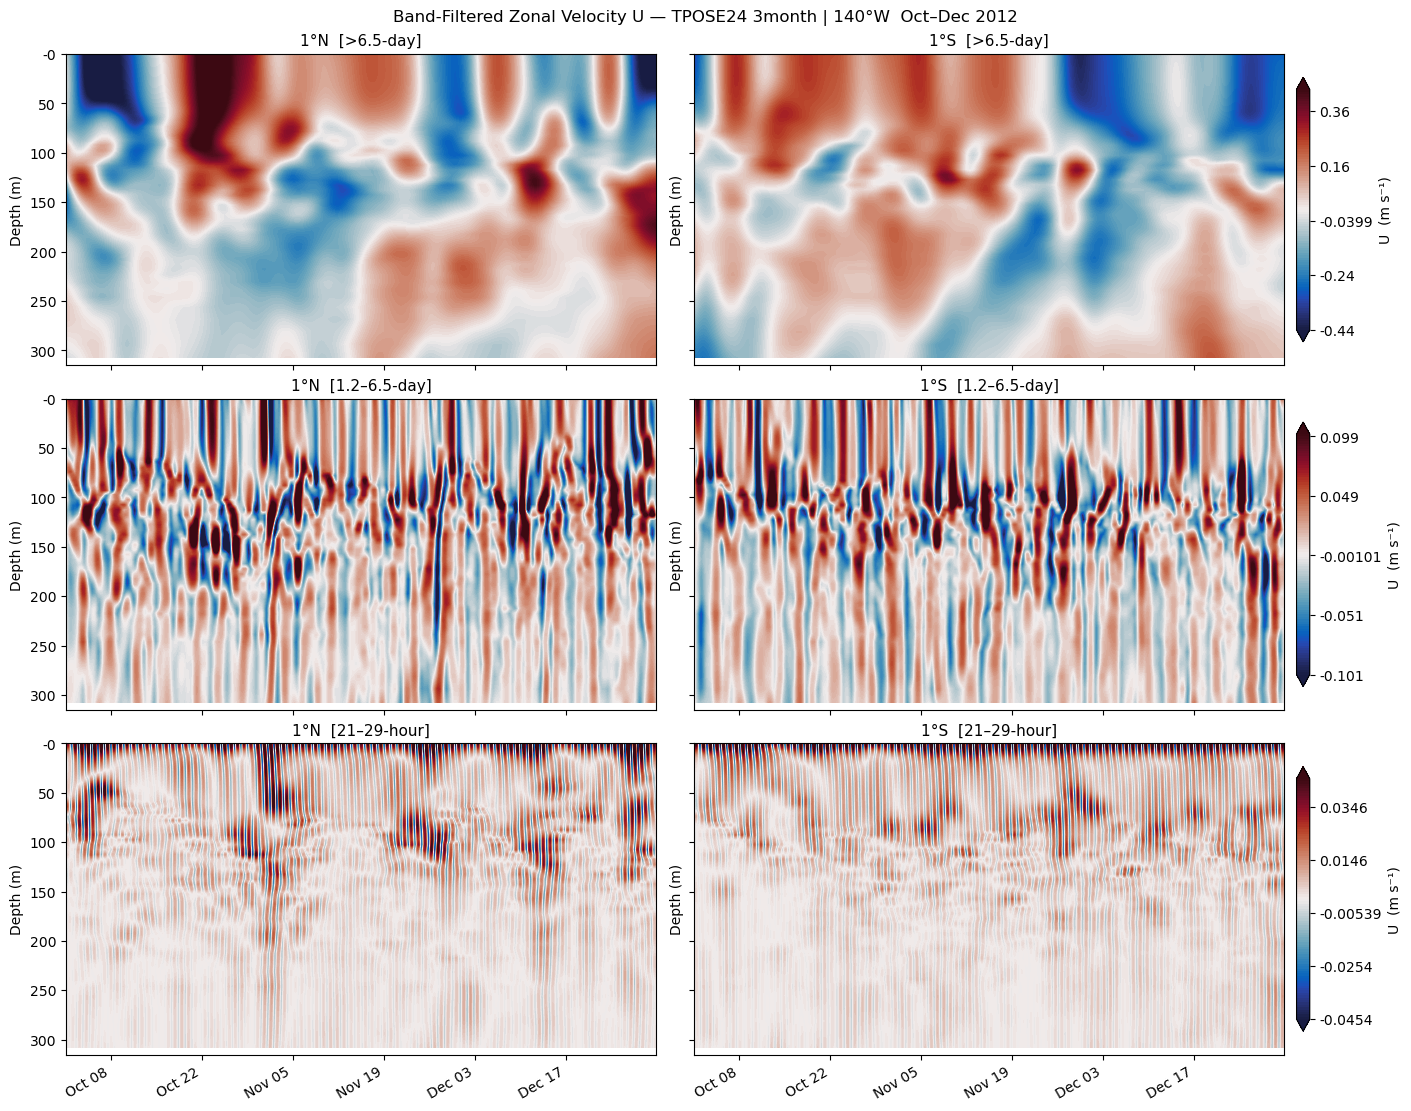

Saved 3month/fig2_wave_stacking_1N_1S_140W.png


In [9]:
t_mod_arr = t_mod.to_pydatetime()

fig2, axes2 = plt.subplots(3, 2, figsize=(14, 11),
                            sharex=True, sharey=True, constrained_layout=True)
fig2.suptitle(f'Band-Filtered Zonal Velocity U — TPOSE24 {SUBFOLDER} | 140°W  Oct–Dec 2012',
              fontsize=12)

vmaxes_fig2 = []
for row, (label, bp) in enumerate(BANDS):
    d1N  = filt_1N[row]
    d1S  = filt_1S[row]
    valid = np.concatenate([d1N[np.isfinite(d1N)], d1S[np.isfinite(d1S)]])
    vmax  = max(np.nanpercentile(np.abs(valid), 97), 0.005)
    vmaxes_fig2.append(vmax)

    cf0 = cf_plot(axes2[row, 0], t_mod_arr, Z_mod, d1N, vmax)
    cf1 = cf_plot(axes2[row, 1], t_mod_arr, Z_mod, d1S, vmax)

    axes2[row, 0].set_title(f'1°N  [{label}]')
    axes2[row, 1].set_title(f'1°S  [{label}]')
    for ax in axes2[row]:
        depth_yax(ax)

    make_colorbar(fig2, cf1, axes2[row], vmax)

for ax in axes2[-1]:
    fmt_time_ax(ax)

out2 = f'{SAVE_DIR}/fig2_wave_stacking_1N_1S_140W.png'
fig2.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', out2)

## 8. Figures 3 & 4 — Zoom: Nov 25 – Dec 15

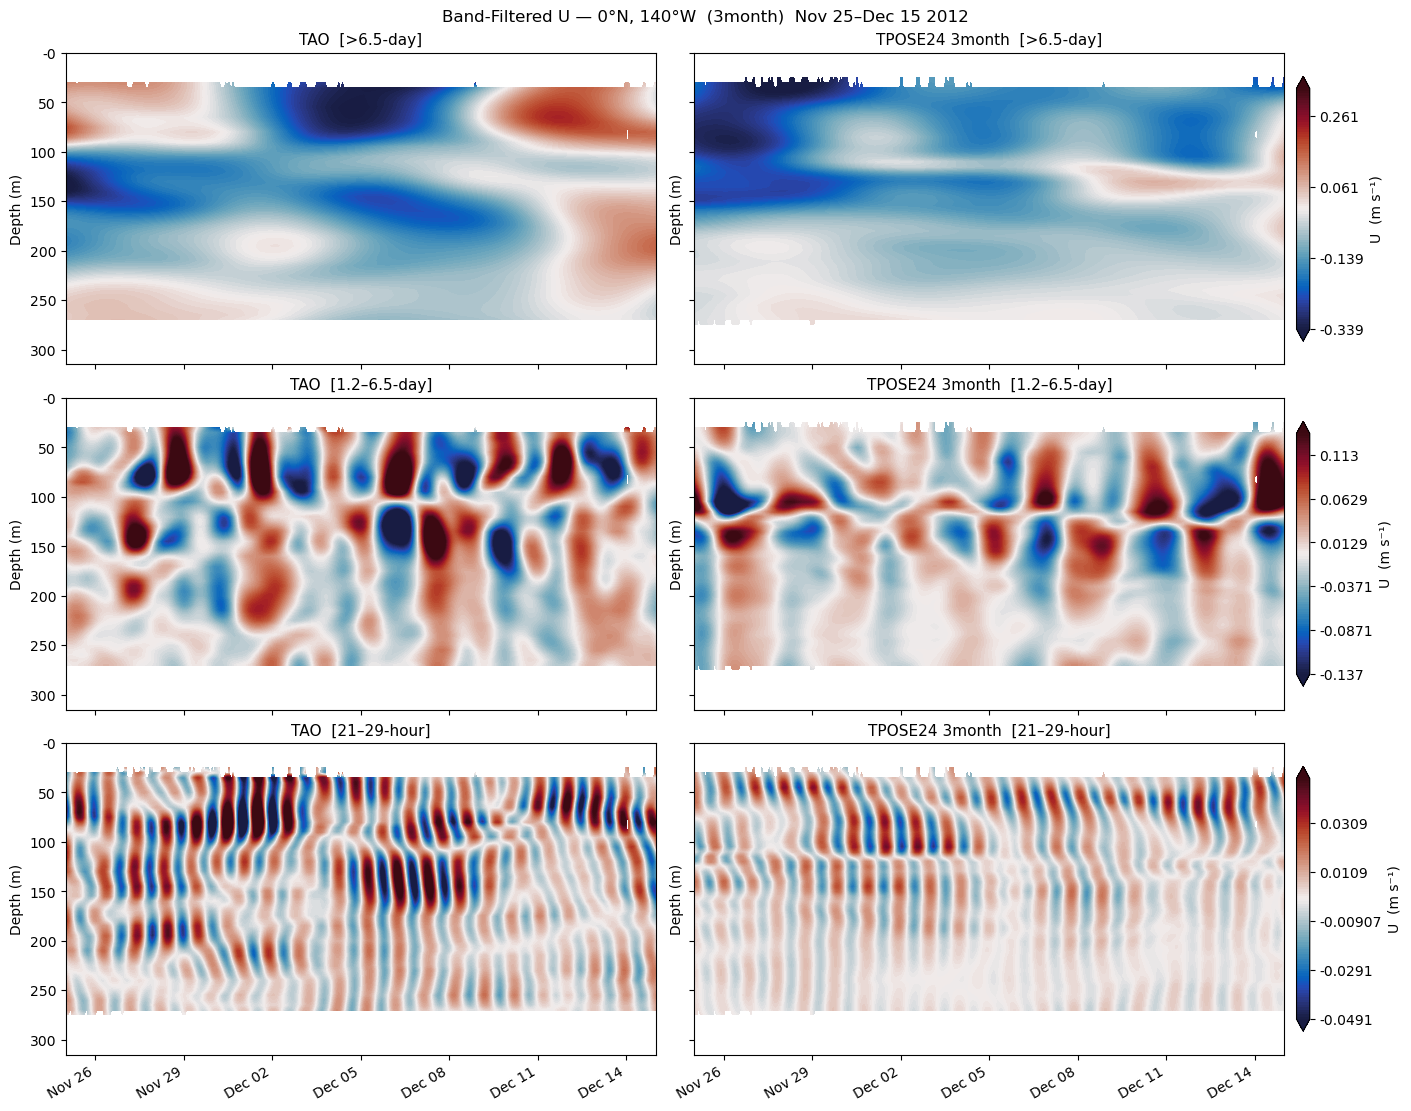

Saved 3month/fig3_wave_stacking_0N_140W_zoom.png


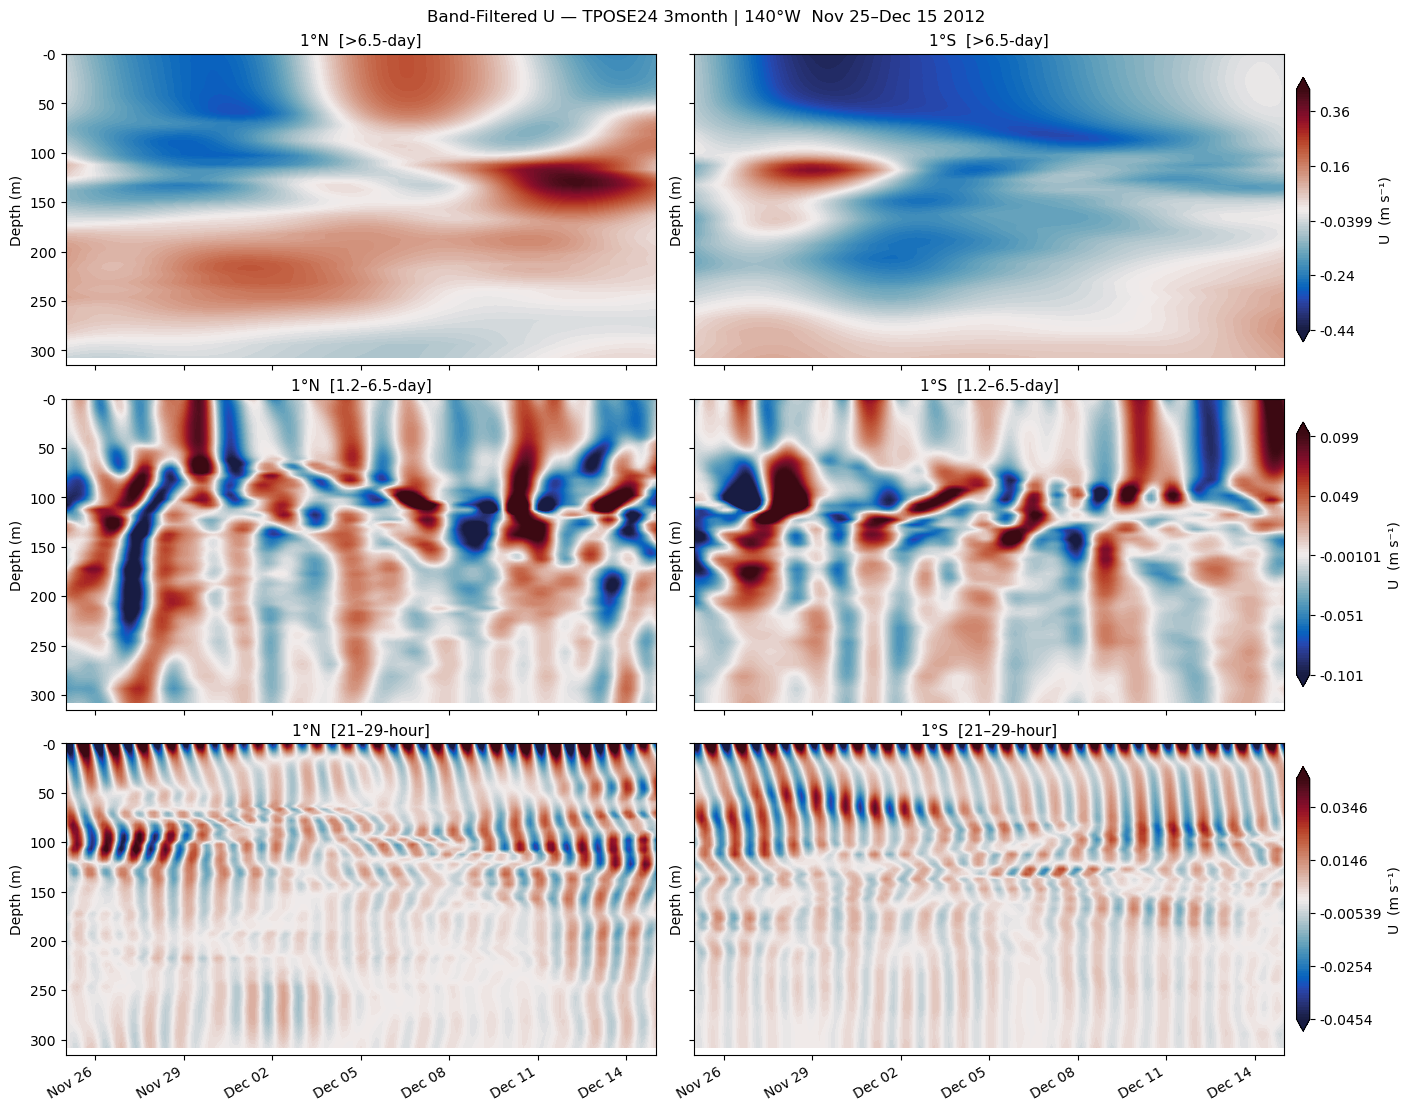

Saved 3month/fig4_wave_stacking_1N_1S_140W_zoom.png


In [10]:
ZOOM_START = pd.Timestamp('2012-11-25')
ZOOM_END   = pd.Timestamp('2012-12-15')

# ── Figure 3: TAO vs TPOSE at 0°N, zoomed ──────────────────────────────────
fig3, axes3 = plt.subplots(3, 2, figsize=(14, 11),
                            sharex=True, sharey=True, constrained_layout=True)
fig3.suptitle(f'Band-Filtered U — 0°N, 140°W  ({SUBFOLDER})  Nov 25–Dec 15 2012',
              fontsize=12)

for row, (label, bp) in enumerate(BANDS):
    vmax = vmaxes_fig1[row]   # reuse full-record scale
    cf0  = cf_plot(axes3[row, 0], t_hrly_arr, Z_tao, filt_tao[row], vmax)
    cf1  = cf_plot(axes3[row, 1], t_hrly_arr, Z_tao, filt_0N[row],  vmax)
    axes3[row, 0].set_title(f'TAO  [{label}]')
    axes3[row, 1].set_title(f'TPOSE24 {SUBFOLDER}  [{label}]')
    for ax in axes3[row]:
        depth_yax(ax)
        ax.set_xlim([ZOOM_START, ZOOM_END])
    make_colorbar(fig3, cf1, axes3[row], vmax)

for ax in axes3[-1]:
    fmt_time_ax(ax, zoom=True)

out3 = f'{SAVE_DIR}/fig3_wave_stacking_0N_140W_zoom.png'
fig3.savefig(out3, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', out3)

# ── Figure 4: TPOSE 1°N vs 1°S, zoomed ────────────────────────────────────
fig4, axes4 = plt.subplots(3, 2, figsize=(14, 11),
                            sharex=True, sharey=True, constrained_layout=True)
fig4.suptitle(f'Band-Filtered U — TPOSE24 {SUBFOLDER} | 140°W  Nov 25–Dec 15 2012',
              fontsize=12)

for row, (label, bp) in enumerate(BANDS):
    vmax = vmaxes_fig2[row]
    cf0  = cf_plot(axes4[row, 0], t_mod_arr, Z_mod, filt_1N[row], vmax)
    cf1  = cf_plot(axes4[row, 1], t_mod_arr, Z_mod, filt_1S[row], vmax)
    axes4[row, 0].set_title(f'1°N  [{label}]')
    axes4[row, 1].set_title(f'1°S  [{label}]')
    for ax in axes4[row]:
        depth_yax(ax)
        ax.set_xlim([ZOOM_START, ZOOM_END])
    make_colorbar(fig4, cf1, axes4[row], vmax)

for ax in axes4[-1]:
    fmt_time_ax(ax, zoom=True)

out4 = f'{SAVE_DIR}/fig4_wave_stacking_1N_1S_140W_zoom.png'
fig4.savefig(out4, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', out4)

## 9. Figures 5 & 6 — Zoom: Nov 25 – Dec 2

In [ ]:
ZOOM2_START = pd.Timestamp('2012-11-25')
ZOOM2_END   = pd.Timestamp('2012-12-02')

# ── Figure 5: TAO vs TPOSE at 0°N ──────────────────────────────────────────
fig5, axes5 = plt.subplots(3, 2, figsize=(14, 11),
                            sharex=True, sharey=True, constrained_layout=True)
fig5.suptitle(f'Band-Filtered U — 0°N, 140°W  ({SUBFOLDER})  Nov 25–Dec 2 2012',
              fontsize=12)

for row, (label, bp) in enumerate(BANDS):
    vmax = vmaxes_fig1[row]
    cf0  = cf_plot(axes5[row, 0], t_hrly_arr, Z_tao, filt_tao[row], vmax)
    cf1  = cf_plot(axes5[row, 1], t_hrly_arr, Z_tao, filt_0N[row],  vmax)
    axes5[row, 0].set_title(f'TAO  [{label}]')
    axes5[row, 1].set_title(f'TPOSE24 {SUBFOLDER}  [{label}]')
    for ax in axes5[row]:
        depth_yax(ax)
        ax.set_xlim([ZOOM2_START, ZOOM2_END])
    make_colorbar(fig5, cf1, axes5[row], vmax)

for ax in axes5[-1]:
    fmt_time_ax(ax, zoom=True)

out5 = f'{SAVE_DIR}/fig5_wave_stacking_0N_140W_zoom2.png'
fig5.savefig(out5, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', out5)

# ── Figure 6: TPOSE 1°N vs 1°S ─────────────────────────────────────────────
fig6, axes6 = plt.subplots(3, 2, figsize=(14, 11),
                            sharex=True, sharey=True, constrained_layout=True)
fig6.suptitle(f'Band-Filtered U — TPOSE24 {SUBFOLDER} | 140°W  Nov 25–Dec 2 2012',
              fontsize=12)

for row, (label, bp) in enumerate(BANDS):
    vmax = vmaxes_fig2[row]
    cf0  = cf_plot(axes6[row, 0], t_mod_arr, Z_mod, filt_1N[row], vmax)
    cf1  = cf_plot(axes6[row, 1], t_mod_arr, Z_mod, filt_1S[row], vmax)
    axes6[row, 0].set_title(f'1°N  [{label}]')
    axes6[row, 1].set_title(f'1°S  [{label}]')
    for ax in axes6[row]:
        depth_yax(ax)
        ax.set_xlim([ZOOM2_START, ZOOM2_END])
    make_colorbar(fig6, cf1, axes6[row], vmax)

for ax in axes6[-1]:
    fmt_time_ax(ax, zoom=True)

out6 = f'{SAVE_DIR}/fig6_wave_stacking_1N_1S_140W_zoom2.png'
fig6.savefig(out6, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', out6)